In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/FedGuard', exist_ok=True)
print("Drive mounted, project folder ready")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted, project folder ready


In [1]:
!pip install flwr scikit-learn pandas numpy torch pycryptodome protobuf==3.20.1

INFO: pip is looking at multiple versions of flwr to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of flwr to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.2/219.2 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 85.9 MB/s eta 0:00

In [1]:
!pip install huggingface_hub

from huggingface_hub import hf_hub_download

path = hf_hub_download(
    repo_id="c01dsnap/CIC-IDS2017",
    filename="Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    repo_type="dataset",
    local_dir="/content/drive/MyDrive/FedGuard/"
)

print("Downloaded to:", path)
DATA_PATH = path

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Friday-WorkingHours-Afternoon-DDos.pcap_(…):   0%|          | 0.00/77.1M [00:00<?, ?B/s]

Downloaded to: /content/drive/MyDrive/FedGuard/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [2]:
import pandas as pd

df = pd.read_csv(DATA_PATH)

# Strip whitespace from column names (CICIDS2017 has leading spaces)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)           # how many rows and columns
print("\nColumns:", df.columns.tolist())
print("\nLabel distribution:")
print(df['Label'].value_counts())   # how many normal vs attack rows
print("\nNull values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])  # find missing data

Shape: (225745, 79)

Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CW

In [3]:
import numpy as np

# Replace infinite values with NaN, then drop those rows
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Convert label to binary: 0 = normal, 1 = attack
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

print("After cleaning:", df.shape)
print("Label distribution after encoding:")
print(df['Label'].value_counts())

After cleaning: (225711, 79)
Label distribution after encoding:
Label
1    128025
0     97686
Name: count, dtype: int64


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features (X) from labels (y)
X = df.drop('Label', axis=1).values   # all 79 columns except label
y = df['Label'].values                 # just the label column

# Normalize: each feature becomes mean=0, std=1
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

# Save the scaler — you'll need the same scaler at inference time
import pickle
with open('/content/drive/MyDrive/FedGuard/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved")

Features shape: (225711, 78)
Labels shape: (225711,)
Scaler saved


In [5]:
import os

# Shuffle the data first so each partition gets a mix of normal + attack
indices = np.random.permutation(len(X))
X, y = X[indices], y[indices]

NUM_CLIENTS = 5
partition_size = len(X) // NUM_CLIENTS

os.makedirs('/content/drive/MyDrive/FedGuard/partitions', exist_ok=True)

for i in range(NUM_CLIENTS):
    start = i * partition_size
    end = start + partition_size if i < NUM_CLIENTS - 1 else len(X)

    X_part = X[start:end]
    y_part = y[start:end]

    np.save(f'/content/drive/MyDrive/FedGuard/partitions/X_client_{i}.npy', X_part)
    np.save(f'/content/drive/MyDrive/FedGuard/partitions/y_client_{i}.npy', y_part)

    attack_pct = y_part.mean() * 100
    print(f"Client {i}: {len(X_part)} samples | {attack_pct:.1f}% attacks")

Client 0: 45142 samples | 56.7% attacks
Client 1: 45142 samples | 56.8% attacks
Client 2: 45142 samples | 56.7% attacks
Client 3: 45142 samples | 56.7% attacks
Client 4: 45143 samples | 56.7% attacks


In [6]:
# Final check — load one partition back and confirm it works
X_test = np.load('/content/drive/MyDrive/FedGuard/partitions/X_client_0.npy')
y_test = np.load('/content/drive/MyDrive/FedGuard/partitions/y_client_0.npy')

print("Partition 0 loaded successfully")
print("X shape:", X_test.shape)
print("y shape:", y_test.shape)
print("Sample features (first row):", X_test[0][:5], "...")
print("Sample label:", y_test[0])

Partition 0 loaded successfully
X shape: (45142, 78)
y shape: (45142,)
Sample features (first row): [-0.44535074 -0.26564456 -0.05675519 -0.21020584 -0.2817569 ] ...
Sample label: 1


In [12]:
import flwr as fl
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from collections import OrderedDict
from Crypto.PublicKey import ECC
from Crypto.Signature import DSS
from Crypto.Hash import SHA256
import hashlib
import json
import sqlite3

# Config — change these freely
NUM_CLIENTS = 5
NUM_ROUNDS = 10
BATCH_SIZE = 256
LOCAL_EPOCHS = 3       # how many epochs each client trains before sending weights
LEARNING_RATE = 0.001
INPUT_FEATURES = 78    # matches your X shape from Day 1

DRIVE_PATH = '/content/drive/MyDrive/FedGuard'

print("All imports done")
print(f"Flower version: {fl.__version__}")

All imports done
Flower version: 1.6.0


In [8]:
class IntrusionDetector(nn.Module):
    def __init__(self):
        super(IntrusionDetector, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(INPUT_FEATURES, 128),  # 78 features → 128 neurons
            nn.ReLU(),
            nn.Dropout(0.3),                 # randomly drop 30% of neurons during training (prevents overfitting)
            nn.Linear(128, 64),              # 128 → 64 neurons
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),               # 64 → 1 output (attack probability)
            nn.Sigmoid()                     # squish output to 0-1 range
        )

    def forward(self, x):
        return self.network(x)

# Test it works
test_model = IntrusionDetector()
test_input = torch.randn(10, 78)   # 10 fake samples, 78 features each
test_output = test_model(test_input)
print("Model output shape:", test_output.shape)   # should be (10, 1)
print("Sample output (probabilities):", test_output[:3].detach().numpy())

Model output shape: torch.Size([10, 1])
Sample output (probabilities): [[0.5548887 ]
 [0.48916623]
 [0.53970313]]


In [9]:
def load_partition(client_id):
    """Load a client's local data partition from Drive"""
    X = np.load(f'{DRIVE_PATH}/partitions/X_client_{client_id}.npy')
    y = np.load(f'{DRIVE_PATH}/partitions/y_client_{client_id}.npy')

    # Convert numpy arrays to PyTorch tensors
    X_tensor = torch.FloatTensor(X)
    y_tensor = torch.FloatTensor(y).unsqueeze(1)  # shape (N,) → (N,1) to match model output

    # Split 80% train, 20% test
    split = int(0.8 * len(X_tensor))
    train_dataset = TensorDataset(X_tensor[:split], y_tensor[:split])
    test_dataset  = TensorDataset(X_tensor[split:], y_tensor[split:])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

    return train_loader, test_loader


def train(model, train_loader):
    """Train the model for LOCAL_EPOCHS on local data"""
    model.train()
    criterion = nn.BCELoss()          # Binary Cross Entropy — standard for binary classification
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    total_loss = 0
    for epoch in range(LOCAL_EPOCHS):
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()           # clear previous gradients
            predictions = model(X_batch)    # forward pass
            loss = criterion(predictions, y_batch)
            loss.backward()                 # compute gradients
            optimizer.step()                # update weights
            total_loss += loss.item()

    return total_loss / (LOCAL_EPOCHS * len(train_loader))


def evaluate(model, test_loader):
    """Evaluate model accuracy on local test data"""
    model.eval()
    criterion = nn.BCELoss()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():    # don't compute gradients during evaluation
        for X_batch, y_batch in test_loader:
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            total_loss += loss.item()

            predicted_labels = (predictions > 0.5).float()   # probability > 0.5 → attack
            correct += (predicted_labels == y_batch).sum().item()
            total += y_batch.size(0)

    accuracy = correct / total
    avg_loss = total_loss / len(test_loader)
    return avg_loss, accuracy

print("Helper functions defined")

Helper functions defined


In [10]:
class FedGuardClient(fl.client.NumPyClient):
    def __init__(self, client_id):
        self.client_id = client_id
        self.model = IntrusionDetector()
        self.train_loader, self.test_loader = load_partition(client_id)

    def get_parameters(self, config):
        # Extract model weights as a list of numpy arrays
        return [val.cpu().numpy() for _, val in self.model.state_dict().items()]

    def set_parameters(self, parameters):
        # Load weights received from the server into local model
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
        self.model.load_state_dict(state_dict, strict=True)

    def fit(self, parameters, config):
        # 1. Receive global model weights from server
        self.set_parameters(parameters)

        # 2. Train locally on our private data
        loss = train(self.model, self.train_loader)

        # 3. Return updated weights + how many samples we trained on
        print(f"  [Client {self.client_id}] Training done | Loss: {loss:.4f}")
        return self.get_parameters(config={}), len(self.train_loader.dataset), {"loss": loss}

    def evaluate(self, parameters, config):
        # 1. Load global model
        self.set_parameters(parameters)

        # 2. Test on local data
        loss, accuracy = evaluate(self.model, self.test_loader)
        print(f"  [Client {self.client_id}] Accuracy: {accuracy:.4f} | Loss: {loss:.4f}")

        # 3. Return results to server
        return loss, len(self.test_loader.dataset), {"accuracy": accuracy}

print("FedGuardClient defined")

FedGuardClient defined


In [13]:
def generate_keypair():
    """Generate an ECDSA keypair using P-256 curve"""
    private_key = ECC.generate(curve='P-256')
    public_key  = private_key.public_key()
    return private_key, public_key

# Generate one keypair per client at startup — simulates each org having their own key
client_keys = {}
for cid in range(NUM_CLIENTS):
    priv, pub = generate_keypair()
    client_keys[cid] = {'private': priv, 'public': pub}
    print(f"Client {cid}: keypair generated ✅")

print("\nAll client keys ready")

Client 0: keypair generated ✅
Client 1: keypair generated ✅
Client 2: keypair generated ✅
Client 3: keypair generated ✅
Client 4: keypair generated ✅

All client keys ready


In [17]:
def sign_weights(weights, private_key):
    """
    Serialize weights → hash them → sign the hash with ECDSA private key
    Returns the signature as bytes
    """
    # Serialize weights to bytes
    weights_bytes = b''.join([w.tobytes() for w in weights])

    # Hash the weights (SHA-256)
    hash_obj = SHA256.new(weights_bytes)

    # Sign the hash with private key
    signer    = DSS.new(private_key, 'fips-186-3')
    signature = signer.sign(hash_obj)

    return signature, hash_obj.hexdigest()  # return sig + hash string for logging

def add_dp_noise(weights, noise_multiplier=0.01, max_grad_norm=1.0):
    """
    Apply differential privacy to weight updates:
    1. Clip each weight tensor to max_grad_norm
    2. Add Gaussian noise scaled by noise_multiplier
    """
    noisy_weights = []
    for w in weights:
        # Step 1: Clip — limit the magnitude of each weight tensor
        norm = np.linalg.norm(w)
        clip_factor = min(1.0, max_grad_norm / (norm + 1e-8))
        clipped = w * clip_factor

        # Step 2: Add Gaussian noise
        noise = np.random.normal(
            loc=0,
            scale=noise_multiplier * max_grad_norm,
            size=w.shape
        ).astype(np.float32)

        noisy_weights.append(clipped + noise)
    return noisy_weights

# Quick test
test_w = [np.ones((3, 3), dtype=np.float32)]
noisy  = add_dp_noise(test_w, noise_multiplier=0.1)
print("Original weights:", test_w[0][0])
print("Noisy weights:   ", noisy[0][0])
print("DP function ready ✅")

def verify_weights(weights, signature, public_key):
    """
    Recompute hash of received weights → verify signature with public key
    Returns True if valid, False if tampered/invalid
    """
    # Recompute the same hash
    weights_bytes = b''.join([w.tobytes() for w in weights])
    hash_obj      = SHA256.new(weights_bytes)

    try:
        verifier = DSS.new(public_key, 'fips-186-3')
        verifier.verify(hash_obj, signature)
        return True    # signature valid
    except ValueError:
        return False   # signature invalid — weights were tampered or wrong key

print("Sign/verify functions defined")

Original weights: [1. 1. 1.]
Noisy weights:    [0.39639866 0.3062861  0.44035894]
DP function ready ✅
Sign/verify functions defined


In [21]:
import sqlite3
import hashlib
import json
import os
from datetime import datetime

DB_PATH = f'{DRIVE_PATH}/fedguard_audit.db'

def init_database():
    conn = sqlite3.connect(DB_PATH)
    c    = conn.cursor()
    c.execute('''
        CREATE TABLE IF NOT EXISTS rounds (
            id               INTEGER PRIMARY KEY AUTOINCREMENT,
            round_num        INTEGER,
            timestamp        TEXT,
            accuracy         REAL,
            model_hash       TEXT,
            dp_enabled       INTEGER,
            noise_multiplier REAL,
            nodes_accepted   TEXT,
            nodes_rejected   TEXT,
            num_accepted     INTEGER,
            num_rejected     INTEGER
        )
    ''')
    c.execute('''
        CREATE TABLE IF NOT EXISTS anomalies (
            id          INTEGER PRIMARY KEY AUTOINCREMENT,
            round_num   INTEGER,
            timestamp   TEXT,
            client_id   INTEGER,
            confidence  REAL,
            flagged_as  TEXT
        )
    ''')
    conn.commit()
    conn.close()
    print(f"Database initialized at {DB_PATH} ✅")

init_database()

Database initialized at /content/drive/MyDrive/FedGuard/fedguard_audit.db ✅


In [22]:
def hash_model(model):
    """SHA-256 hash of the model's weights"""
    weights_bytes = b''.join([
        val.cpu().numpy().tobytes()
        for val in model.state_dict().values()
    ])
    return hashlib.sha256(weights_bytes).hexdigest()

# Test it
test_hash = hash_model(global_model)
print(f"Model hash: {test_hash}")
print(f"Hash length: {len(test_hash)} chars")

Model hash: 162aeba37efeee595c12864f51a3053cdb1156e63021a9b2c939f327930c8973
Hash length: 64 chars


In [23]:
def detect_anomalies(model, round_num, threshold=0.95):
    """
    Run global model on client 0's test data
    Flag samples where attack confidence > threshold
    Returns list of anomaly dicts
    """
    model.eval()
    _, test_loader = load_partition(0)
    anomalies = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = model(X_batch).squeeze()
            for i, conf in enumerate(preds):
                if conf.item() > threshold and y_batch[i].item() == 1:
                    anomalies.append({
                        'confidence': round(conf.item(), 4),
                        'actual':     int(y_batch[i].item())
                    })
            if len(anomalies) >= 20:   # cap at 20 per round
                break

    return anomalies[:20]

print("Anomaly detection ready ✅")

Anomaly detection ready ✅


In [24]:
NOISE_MULTIPLIER = 0.01
MAX_GRAD_NORM    = 1.0
DP_ENABLED       = True

round_accuracies = []
global_model     = IntrusionDetector()

def get_weights(model):
    return [val.cpu().numpy() for val in model.state_dict().values()]

def set_weights(model, weights):
    state_dict = dict(zip(model.state_dict().keys(),
                          [torch.tensor(w) for w in weights]))
    model.load_state_dict(state_dict, strict=True)

def write_round_to_db(round_data):
    conn = sqlite3.connect(DB_PATH)
    c    = conn.cursor()
    c.execute('''
        INSERT INTO rounds
        (round_num, timestamp, accuracy, model_hash, dp_enabled,
         noise_multiplier, nodes_accepted, nodes_rejected, num_accepted, num_rejected)
        VALUES (?,?,?,?,?,?,?,?,?,?)
    ''', (
        round_data['round'],
        round_data['timestamp'],
        round_data['accuracy'],
        round_data['model_hash'],
        int(round_data['dp_enabled']),
        round_data['noise_multiplier'],
        json.dumps(round_data['nodes_accepted']),
        json.dumps(round_data['nodes_rejected']),
        round_data['num_accepted'],
        round_data['num_rejected'],
    ))
    conn.commit()
    conn.close()

def write_anomalies_to_db(anomalies, round_num, client_id=0):
    conn = sqlite3.connect(DB_PATH)
    c    = conn.cursor()
    for a in anomalies:
        c.execute('''
            INSERT INTO anomalies (round_num, timestamp, client_id, confidence, flagged_as)
            VALUES (?,?,?,?,?)
        ''', (
            round_num,
            datetime.now().isoformat(),
            client_id,
            a['confidence'],
            'DDoS'
        ))
    conn.commit()
    conn.close()

print("Starting FedGuard — Full Pipeline (ECDSA + DP + SHA-256 + Audit Log)")
print(f"DP: {DP_ENABLED} | Noise: {NOISE_MULTIPLIER} | Clients: {NUM_CLIENTS} | Rounds: {NUM_ROUNDS}\n")

for round_num in range(1, NUM_ROUNDS + 1):
    print(f"--- Round {round_num} ---")

    global_weights = get_weights(global_model)
    client_weights = []
    client_sizes   = []
    nodes_accepted = []
    nodes_rejected = []

    for cid in range(NUM_CLIENTS):
        local_model = IntrusionDetector()
        set_weights(local_model, global_weights)
        train_loader, _ = load_partition(cid)
        loss = train(local_model, train_loader)
        local_weights = get_weights(local_model)

        # Differential Privacy
        if DP_ENABLED:
            local_weights = add_dp_noise(local_weights, NOISE_MULTIPLIER, MAX_GRAD_NORM)

        # ECDSA sign + verify
        signature, w_hash = sign_weights(local_weights, client_keys[cid]['private'])
        is_valid = verify_weights(local_weights, signature, client_keys[cid]['public'])

        if is_valid:
            print(f"  [Client {cid}] ✅ Verified | Loss: {loss:.4f}")
            client_weights.append(local_weights)
            client_sizes.append(len(train_loader.dataset))
            nodes_accepted.append(cid)
        else:
            print(f"  [Client {cid}] ❌ REJECTED")
            nodes_rejected.append(cid)

    if not client_weights:
        print("⚠️  No valid updates — skipping")
        continue

    # FedAvg
    total = sum(client_sizes)
    averaged_weights = [
        sum(client_weights[c][i] * (client_sizes[c] / total)
            for c in range(len(client_weights)))
        for i in range(len(global_weights))
    ]
    set_weights(global_model, averaged_weights)

    # Evaluate
    total_correct, total_samples = 0, 0
    for cid in range(NUM_CLIENTS):
        _, test_loader = load_partition(cid)
        _, acc = evaluate(global_model, test_loader)
        total_correct += acc * len(test_loader.dataset)
        total_samples += len(test_loader.dataset)

    global_acc = total_correct / total_samples
    round_accuracies.append(global_acc)

    # SHA-256 hash of global model
    model_hash = hash_model(global_model)

    # Detect anomalies
    anomalies = detect_anomalies(global_model, round_num)

    # Write to SQLite
    round_data = {
        'round':           round_num,
        'timestamp':       datetime.now().isoformat(),
        'accuracy':        round(global_acc, 6),
        'model_hash':      model_hash,
        'dp_enabled':      DP_ENABLED,
        'noise_multiplier':NOISE_MULTIPLIER,
        'nodes_accepted':  nodes_accepted,
        'nodes_rejected':  nodes_rejected,
        'num_accepted':    len(nodes_accepted),
        'num_rejected':    len(nodes_rejected),
    }
    write_round_to_db(round_data)
    write_anomalies_to_db(anomalies, round_num)

    print(f"\n>>> Round {round_num} | Hash: {model_hash[:16]}... | Accuracy: {global_acc:.4f} | Anomalies: {len(anomalies)}\n")

print("Simulation complete!")
torch.save(global_model.state_dict(), f'{DRIVE_PATH}/global_model.pth')
print("Model saved ✅")

Starting FedGuard — Full Pipeline (ECDSA + DP + SHA-256 + Audit Log)
DP: True | Noise: 0.01 | Clients: 5 | Rounds: 10

--- Round 1 ---
  [Client 0] ✅ Verified | Loss: 0.0521
  [Client 1] ✅ Verified | Loss: 0.0522
  [Client 2] ✅ Verified | Loss: 0.0541
  [Client 3] ✅ Verified | Loss: 0.0528
  [Client 4] ✅ Verified | Loss: 0.0522

>>> Round 1 | Hash: f07317d8638ed004... | Accuracy: 0.9788 | Anomalies: 0

--- Round 2 ---
  [Client 0] ✅ Verified | Loss: 0.0328
  [Client 1] ✅ Verified | Loss: 0.0326
  [Client 2] ✅ Verified | Loss: 0.0337
  [Client 3] ✅ Verified | Loss: 0.0310
  [Client 4] ✅ Verified | Loss: 0.0322

>>> Round 2 | Hash: 7a89dfec8e41d8c5... | Accuracy: 0.9859 | Anomalies: 0

--- Round 3 ---
  [Client 0] ✅ Verified | Loss: 0.0266
  [Client 1] ✅ Verified | Loss: 0.0274
  [Client 2] ✅ Verified | Loss: 0.0276
  [Client 3] ✅ Verified | Loss: 0.0259
  [Client 4] ✅ Verified | Loss: 0.0287

>>> Round 3 | Hash: 4d82149bf4e41a96... | Accuracy: 0.9866 | Anomalies: 0

--- Round 4 ---
  [C

In [25]:
conn = sqlite3.connect(DB_PATH)
c    = conn.cursor()

print("=== ROUNDS TABLE ===")
c.execute("SELECT round_num, timestamp, accuracy, model_hash, num_accepted, num_rejected FROM rounds")
for row in c.fetchall():
    print(f"Round {row[0]} | Acc: {row[2]:.4f} | Hash: {row[3][:20]}... | Accepted: {row[4]} | Rejected: {row[5]}")

print(f"\n=== ANOMALIES TABLE ===")
c.execute("SELECT round_num, client_id, confidence, flagged_as FROM anomalies LIMIT 10")
for row in c.fetchall():
    print(f"Round {row[0]} | Client {row[1]} | Confidence: {row[2]} | Type: {row[3]}")

conn.close()

=== ROUNDS TABLE ===
Round 1 | Acc: 0.9788 | Hash: f07317d8638ed0049f3f... | Accepted: 5 | Rejected: 0
Round 2 | Acc: 0.9859 | Hash: 7a89dfec8e41d8c5bd4c... | Accepted: 5 | Rejected: 0
Round 3 | Acc: 0.9866 | Hash: 4d82149bf4e41a968202... | Accepted: 5 | Rejected: 0
Round 4 | Acc: 0.9863 | Hash: 4ed7ef974f7a33c0376b... | Accepted: 5 | Rejected: 0
Round 5 | Acc: 0.9883 | Hash: 0f518091f5a6c66508ed... | Accepted: 5 | Rejected: 0
Round 6 | Acc: 0.9914 | Hash: 504081918067526d521c... | Accepted: 5 | Rejected: 0
Round 7 | Acc: 0.9875 | Hash: 1bd73b0b9072c1ffaa95... | Accepted: 5 | Rejected: 0
Round 8 | Acc: 0.9921 | Hash: df775efbe3414119d59a... | Accepted: 5 | Rejected: 0
Round 9 | Acc: 0.9913 | Hash: 9e8fd33dc18e7d90b203... | Accepted: 5 | Rejected: 0
Round 10 | Acc: 0.9915 | Hash: 0e9dd80111d663b1cd6d... | Accepted: 5 | Rejected: 0

=== ANOMALIES TABLE ===


In [26]:
from google.colab import files
files.download(DB_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
from google.colab import files
files.download(f'{DRIVE_PATH}/fedguard_audit.db')
files.download(f'{DRIVE_PATH}/global_model.pth')
files.download(f'{DRIVE_PATH}/scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
print("=== Attack Simulation Test ===\n")

# Get current global weights
test_weights = get_weights(global_model)

# Sign with Client 0's key
priv_0      = client_keys[0]['private']
pub_0       = client_keys[0]['public']
sig, _      = sign_weights(test_weights, priv_0)

# Valid verification
result = verify_weights(test_weights, sig, pub_0)
print(f"Valid signature check:    {'✅ ACCEPTED' if result else '❌ REJECTED'}")

# Tampered weights — modify one value
tampered_weights         = [w.copy() for w in test_weights]
tampered_weights[0][0,0] = 999.0   # inject garbage value

result2 = verify_weights(tampered_weights, sig, pub_0)
print(f"Tampered weights check:   {'✅ ACCEPTED' if result2 else '❌ REJECTED'}")

# Wrong key — verify with Client 1's key
pub_1   = client_keys[1]['public']
result3 = verify_weights(test_weights, sig, pub_1)
print(f"Wrong public key check:   {'✅ ACCEPTED' if result3 else '❌ REJECTED'}")

=== Attack Simulation Test ===

Valid signature check:    ✅ ACCEPTED
Tampered weights check:   ❌ REJECTED
Wrong public key check:   ❌ REJECTED


Noise=0.001 → Accuracy: 99.68%
Noise=0.010 → Accuracy: 98.76%
Noise=0.050 → Accuracy: 92.23%
Noise=0.100 → Accuracy: 70.18%
Noise=0.500 → Accuracy: 42.93%
Noise=1.000 → Accuracy: 55.12%


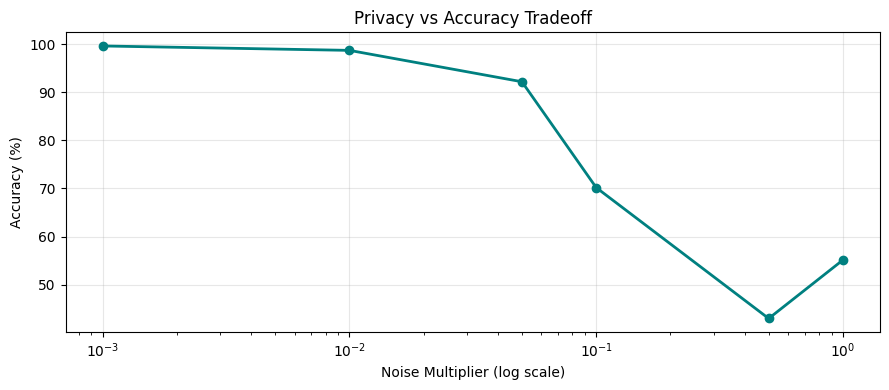

In [19]:
import matplotlib.pyplot as plt

noise_levels  = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
final_accs    = []

for noise in noise_levels:
    test_model = IntrusionDetector()
    gw = get_weights(IntrusionDetector())  # fresh global

    for r in range(3):   # quick 3-round test
        cw, cs = [], []
        for cid in range(NUM_CLIENTS):
            lm = IntrusionDetector()
            set_weights(lm, gw)
            tl, _ = load_partition(cid)
            train(lm, tl)
            w = add_dp_noise(get_weights(lm), noise_multiplier=noise)
            cw.append(w)
            cs.append(len(tl.dataset))
        total = sum(cs)
        gw = [sum(cw[c][i]*(cs[c]/total) for c in range(NUM_CLIENTS))
              for i in range(len(gw))]
    set_weights(test_model, gw)
    _, tl = load_partition(0)
    _, acc = evaluate(test_model, tl)
    final_accs.append(acc * 100)
    print(f"Noise={noise:.3f} → Accuracy: {acc*100:.2f}%")

plt.figure(figsize=(9, 4))
plt.plot(noise_levels, final_accs, marker='o', color='teal', linewidth=2)
plt.xscale('log')
plt.xlabel('Noise Multiplier (log scale)')
plt.ylabel('Accuracy (%)')
plt.title('Privacy vs Accuracy Tradeoff')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/dp_tradeoff.png', dpi=150)
plt.show()

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pickle

# 1. Define the architecture (must match exactly what you trained)
class IntrusionDetector(nn.Module):
    def __init__(self):
        super(IntrusionDetector, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(78, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x)

# 2. Load model + scaler
model = IntrusionDetector()
model.load_state_dict(torch.load('global_model.pth', map_location='cpu'))
model.eval()   # disables dropout for inference

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# 3. Predict function
def predict(raw_features: list) -> dict:
    """
    raw_features: a list of 78 raw network traffic values
                  (same columns as CICIDS2017, in same order, unnormalized)
    returns: dict with label and confidence
    """
    # Scale using the same scaler from training
    scaled = scaler.transform([raw_features])          # shape (1, 78)
    tensor = torch.FloatTensor(scaled)                 # → PyTorch tensor

    with torch.no_grad():                              # no gradient needed
        confidence = model(tensor).item()              # single float 0.0–1.0

    label = "ATTACK" if confidence > 0.5 else "BENIGN"
    return {
        "label":      label,
        "confidence": round(confidence, 4),
        "attack":     confidence > 0.5
    }

# 4. Test with a fake sample
fake_sample = [0.0] * 78   # replace with real values
result = predict(fake_sample)
print(result)
# → {'label': 'BENIGN', 'confidence': 0.0312, 'attack': False}